In [7]:
import pandas as pd 
import numpy as np 
import mlflow 
import dagshub 

# Replace with your actual username and repo name
dagshub.init(repo_owner='amarpoji', repo_name='ai-fraud-detector', mlflow=True)

# read the dataset using pandas
data_path = "../data/raw/email_dataset.csv" 
df = pd.read_csv(data_path)
display(df.head(10))

Accessing as amarpoji

Initialized MLflow to track repo "amarpoji/ai-fraud-detector"

Repository amarpoji/ai-fraud-detector initialized!

,text,label,phishing_type,severity,confidence
0,Subject: Office maintenance\n\nThanks for your...,0,legitimate,low,0.95
1,"Hello, your profile has been locked. Use the s...",1,credential_harvesting,high,0.89
2,"Hi there, congratulations! You are the winner ...",1,financial_scam,medium,0.69
3,"Attention, this is the fraud prevention accoun...",1,authority_scam,high,0.91
4,"Notice, your profile has been restricted. Use ...",1,credential_harvesting,high,0.80
5,"Attention, this is an urgent notice regarding ...",1,urgency,medium,0.74
6,Subject: Training session notes\n\nI booked th...,0,legitimate,low,0.95
7,Subject: Meeting follow-up\n\nThanks for atten...,0,legitimate,low,0.99
8,"Subject: Research discussion\n\nGood morning, ...",0,legitimate,low,0.98
9,"Attention, your account has been restricted. U...",1,credential_harvesting,high,0.88


In [11]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

# Download required NLTK data
nltk.download('punkt_tab')
nltk.download('stopwords')

def clean_text(text):
  """
  Clean text by:
  1. Converting to lowercase
  2. Removing punctuation/special characters (except URLs)
  3. Tokenizing into words
  4. Removing stopwords
  """
  # Convert to lowercase
  text = text.lower()
  
  # Remove punctuation except those in URLs
  text = re.sub(r'[^\w\s:/.]', '', text)
  
  # Tokenize
  tokens = word_tokenize(text)
  
  # Remove stopwords
  stop_words = set(stopwords.words('english'))
  tokens = [token for token in tokens if token not in stop_words and len(token) > 1]
  
  return " ".join(tokens)

# Apply the function to the 'text' column
df['cleaned_text'] = df['text'].apply(clean_text)
display(df[['text', 'cleaned_text']].head())

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,cleaned_text
0,Subject: Office maintenance\n\nThanks for your...,subject office maintenance thanks help analysi...
1,"Hello, your profile has been locked. Use the s...",hello profile locked use secure link verify us...
2,"Hi there, congratulations! You are the winner ...",hi congratulations winner refund collect gift ...
3,"Attention, this is the fraud prevention accoun...",attention fraud prevention accounts team secur...
4,"Notice, your profile has been restricted. Use ...",notice profile restricted use secure link rese...


In [20]:
print(df['text'][1])
print(df['cleaned_text'][1])

Hello, your profile has been locked. Use the secure link to verify your username and restore access. Enter your verification code to continue.

Keywords: pin update password sign in settings password

Sincerely,
Riley Khan
hello profile locked use secure link verify username restore access enter verification code continue keywords pin update password sign settings password sincerely riley khan


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  df['cleaned_text'], 
  df['label'], 
  test_size=0.2, 
  random_state=42
)

# Create and fit TF-IDF vectorizer on training data only
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

print(f"Training set shape: {X_train_vectorized.shape}")
print(f"Testing set shape: {X_test_vectorized.shape}")

Training set shape: (8000, 5000)
Testing set shape: (2000, 5000)


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Start MLflow experiment
mlflow.set_experiment("email-phishing-detection")

with mlflow.start_run():
  # Log parameters
  mlflow.log_param("model_type", "RandomForest")
  mlflow.log_param("n_estimators", 100)
  mlflow.log_param("max_depth", 15)
  mlflow.log_param("random_state", 42)
  
  # Train model
  model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
  model.fit(X_train_vectorized, y_train)
  
  # Make predictions
  y_pred = model.predict(X_test_vectorized)
  
  # Calculate metrics
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  
  # Log metrics
  mlflow.log_metric("accuracy", accuracy)
  mlflow.log_metric("precision", precision)
  mlflow.log_metric("recall", recall)
  mlflow.log_metric("f1_score", f1)
  
  # Log model
  mlflow.sklearn.log_model(model, "model")
  
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1-Score: {f1:.4f}")

2026/04/06 03:08:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 03:08:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/06 03:10:53 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\USER\AppData\Local\Temp\tmp1g0p6twe\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.7.2', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
🏃 View run traveling-squid-109 at: https://dagshub.com/amarpoji/ai-fraud-detector.mlflow/#/experiments/1/runs/a1b0fc80311c46d69fd5c782eae48a07
🧪 View experiment at: https://dagshub.com/amarpoji/ai-fraud-detector.mlflow/#/experiments/1


In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming you used TfidfVectorizer or CountVectorizer
importances = model.feature_importances_
feature_names = vectorizer.get_feature_names_out()
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
print(feature_importance_df.sort_values(by='importance', ascending=False).head(10))

           feature  importance
2182      keywords    0.057521
4137       subject    0.055433
1503           for    0.050054
503           best    0.036137
4506            to    0.026919
84         account    0.026235
4367           the    0.022924
314            are    0.022564
4366    thanks for    0.019711
4978  your account    0.016906


Confusion Matrix:
[[ 779    0]
 [   0 1221]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       779
           1       1.00      1.00      1.00      1221

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



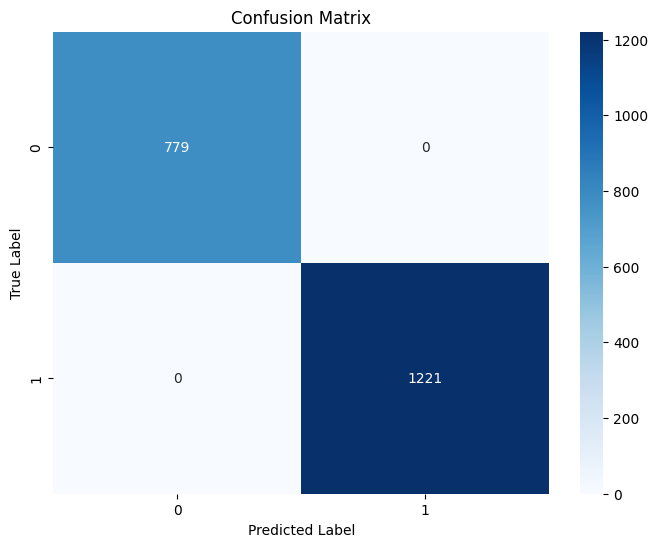


Class distribution in test set:
label
1    1221
0     779
Name: count, dtype: int64

Prediction distribution:
1    1221
0     779
Name: count, dtype: int64


In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

import matplotlib.pyplot as plt

# Check confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Check for class imbalance
print("\nClass distribution in test set:")
print(y_test.value_counts())

# Check prediction distribution
print("\nPrediction distribution:")
print(pd.Series(y_pred).value_counts())

In [28]:
last_run = mlflow.last_active_run()
print(f"The last Run ID was: {last_run.info.run_id}")

The last Run ID was: a1b0fc80311c46d69fd5c782eae48a07


In [9]:
# Load the model from MLflow
model_name = "scam_detector_rf_v1"
model_version = "latest"

model_uri = f"models:/{model_name}/{model_version}" 
loaded_model = mlflow.sklearn.load_model(model_uri)

### example of spam email

In [25]:

# Test with a sample email
sample_spam_email = "You are the lucky winner of a $1,000 Amazon Gift Card from our monthly loyalty drawing.To claim your prize, simply click the link below and provide your shipping details and a small $1.99 processing fee.Claim My $1,000 Gift Card HereNote: This offer expires in 12 hours. If you do not claim it, we will select another winner.Regards,The Rewards Department"

cleaned_sample = clean_text(sample_spam_email)
sample_vectorized = vectorizer.transform([cleaned_sample])

# Make prediction
prediction = loaded_model.predict(sample_vectorized)
prediction_proba = loaded_model.predict_proba(sample_vectorized)

print(f"Original email: {sample_email}")
print(f"Cleaned email: {cleaned_sample}")
print(f"Prediction: {'Phishing' if prediction[0] == 1 else 'Legitimate'}")
print(f"Confidence: {max(prediction_proba[0]):.4f}")

Original email: You are the lucky winner of a $1,000 Amazon Gift Card from our monthly loyalty drawing.To claim your prize, simply click the link below and provide your shipping details and a small $1.99 processing fee.Claim My $1,000 Gift Card HereNote: This offer expires in 12 hours. If you do not claim it, we will select another winner.Regards,The Rewards Department
Cleaned email: lucky winner 1000 amazon gift card monthly loyalty drawing.to claim prize simply click link provide shipping details small 1.99 processing fee.claim 1000 gift card herenote offer expires 12 hours claim select another winner.regardsthe rewards department
Prediction: Phishing
Confidence: 0.8169


### example of legit email

In [27]:
# Test with a sample email
sample_legit_email = "Subject: Project updateGood morning, the updated agenda for next week is included below. Please check your items and add commentsAppreciate your feedback on this draft.Best,Jamie Patel"

cleaned_sample = clean_text(sample_legit_email)
sample_vectorized = vectorizer.transform([cleaned_sample])

# Make prediction
prediction = loaded_model.predict(sample_vectorized)
prediction_proba = loaded_model.predict_proba(sample_vectorized)

print(f"Original email: {sample_legit_email}")
print(f"Cleaned email: {cleaned_sample}")
print(f"Prediction: {'Phishing' if prediction[0] == 1 else 'Legitimate'}")
print(f"Confidence: {max(prediction_proba[0]):.4f}")

Original email: Subject: Project updateGood morning, the updated agenda for next week is included below. Please check your items and add commentsAppreciate your feedback on this draft.Best,Jamie Patel
Cleaned email: subject project updategood morning updated agenda next week included please check items add commentsappreciate feedback draft.bestjamie patel
Prediction: Legitimate
Confidence: 0.8792
